## 1. Import data, libraries & config

In [1]:
from pathlib import Path
import sys
import pandas as pd

PROJECT_DIR = Path.cwd().resolve().parents[0]
sys.path.append(str(PROJECT_DIR))

from src.eda import (
    EDAConfig,
    overview_table, desribe_numeric,
    plot_distributions, plot_pairwise, plot_corr_heatmap,
    pca_2d, pca_loadings, plot_pca_scatter,
    age_bins, quantile_bins, boxplot_by_group, run_group_difference_test, summarize_group_test, 
    group_descriptives, dunn_posthoc_holm, significant_pairs_from_pmat
)

FEATURE_COLS = ["Age", "Annual_income_thousands", "Spending_score"]
CAT_COL = "Gender"
VALUE_COL = "Spending_score"
AGE_GROUP_COL = "Age_group"
INCOME_GROUP_COL = "Income_group"

## 2. Load processed data

In [2]:
data_path = PROJECT_DIR / "data" / "processed" / "model_table.csv"
df = pd.read_csv(data_path)

df.head()

,Age,Annual_income_thousands,Spending_score,Gender
0,19,15,39,Male
1,21,15,81,Male
2,20,16,6,Female
3,23,16,77,Female
4,31,17,40,Female


## 3. Data checks

In [3]:
print(df.shape)
print(overview_table(df))
print(desribe_numeric(df, FEATURE_COLS))

(200, 4)
                         dtype  missing  missing %  nunique
Spending_score           int64        0        0.0       84
Annual_income_thousands  int64        0        0.0       64
Age                      int64        0        0.0       51
Gender                     str        0        0.0        2
                         count   mean        std   min    25%   50%   75%  \
Age                      200.0  38.85  13.969007  18.0  28.75  36.0  49.0   
Annual_income_thousands  200.0  60.56  26.264721  15.0  41.50  61.5  78.0   
Spending_score           200.0  50.20  25.823522   1.0  34.75  50.0  73.0   

                           max  
Age                       70.0  
Annual_income_thousands  137.0  
Spending_score            99.0  


## 4. Plot distributions

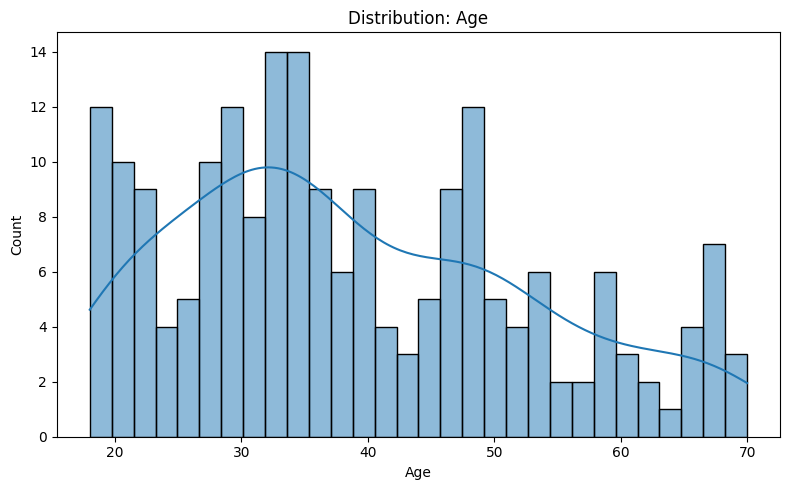

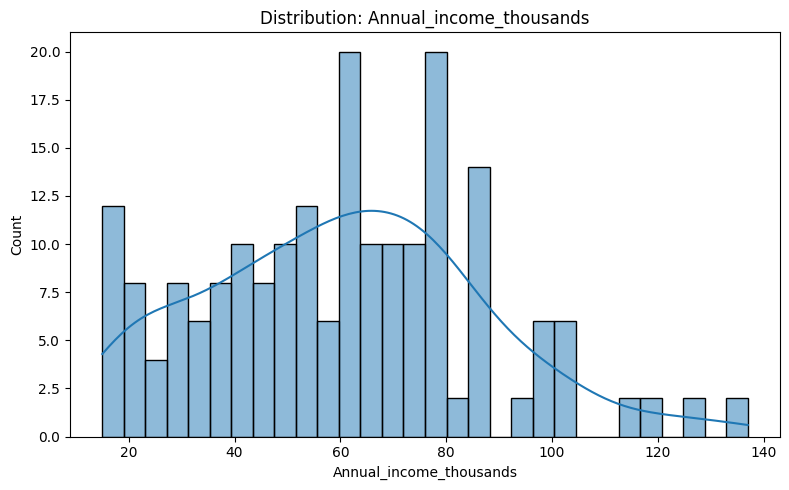

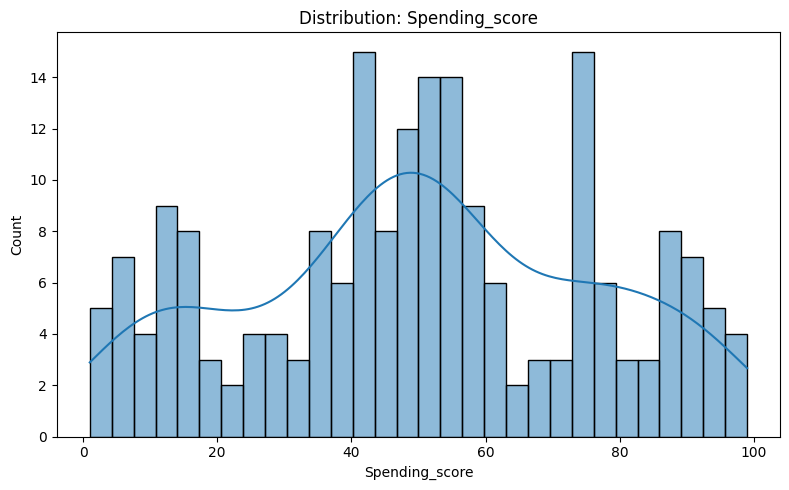

In [4]:
plot_distributions(df, FEATURE_COLS, bins=30)

## 5. Correlations and relationships

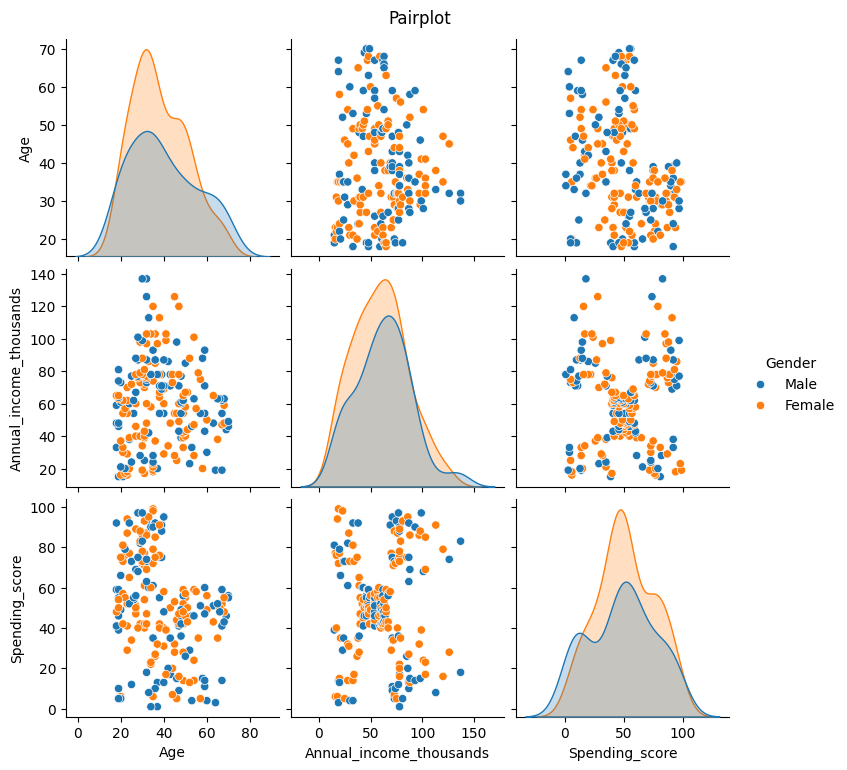

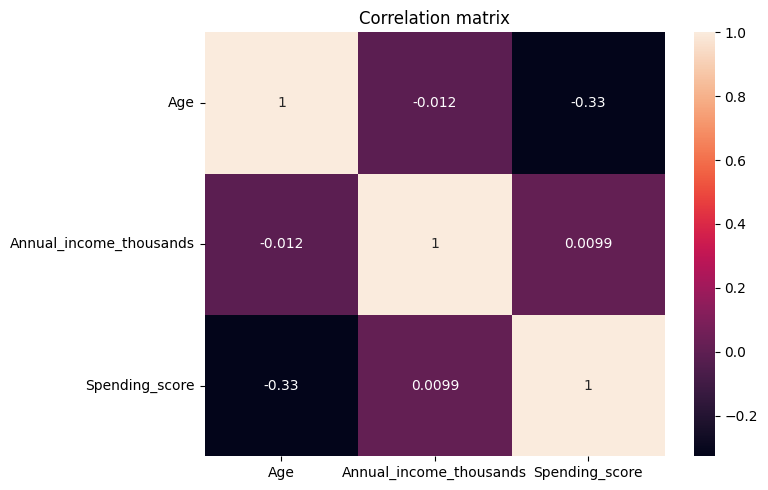

In [5]:
plot_pairwise(df, FEATURE_COLS, hue=CAT_COL, diag_kind="kde", sample=800)
plot_corr_heatmap(df, FEATURE_COLS)

## 6. PCA

In [6]:
proj, pca, scaler = pca_2d(df, FEATURE_COLS, standardize=True)

print("Explained variance ration (PC1, PC2):", pca.explained_variance_ratio_)
print("Total explained by PC1 + PC2:", pca.explained_variance_ratio_.sum())

loadings = pca_loadings(pca, FEATURE_COLS)
loadings

Explained variance ration (PC1, PC2): [0.44266167 0.33308378]
Total explained by PC1 + PC2: 0.7757454566976747


,PC1,PC2
Age,0.706382,0.030141
Annual_income_thousands,-0.048024,0.998832
Spending_score,-0.706199,-0.037775


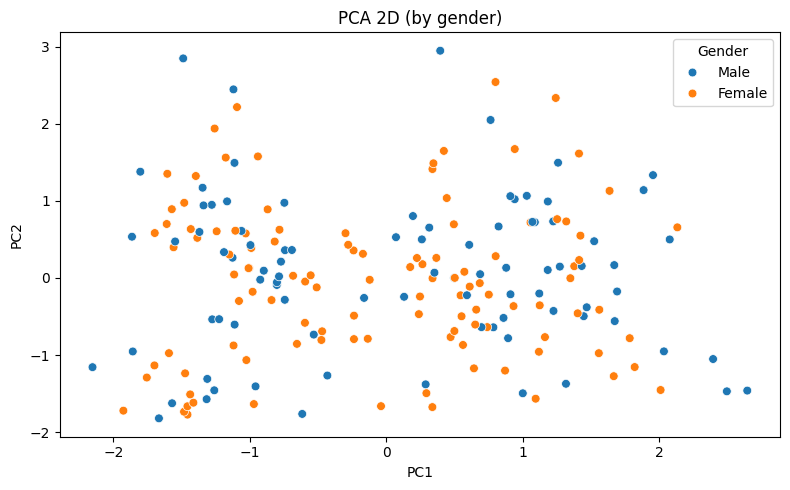

In [7]:
plot_pca_scatter(proj, hue=df[CAT_COL], title="PCA 2D (by gender)")

## 7. Hypothesis testing  

### Based on EDA, we ran exploratory tests to see whether mean spending differs across age and income groups.
### We bin the age in 5 grpups:  
18-24: Young adults  
25-34: Young professionals  
35-44: Mid-career adults  
45-54: Pre-retirement individuals  
55-70: Older adults / retired  
### Income into 4 groups based on the quartiles location:  
<25% - Low  
25% - 50% - Mid-low  
50% - 75% - Mid-high  
\>75% - High

## 7.1 Binning

In [8]:
df = age_bins(df, age_col="Age", new_col="Age_group")

df = quantile_bins(
    df,
    col="Annual_income_thousands",
    new_col="Income_group",
    q=4,
    labels=["Q1 (low)", "Q2 (mid-low)", "Q3 (mid-high)", "Q4 (high)"],
)

df[["Age", "Age_group", "Annual_income_thousands", "Income_group", "Spending_score"]].head()

,Age,Age_group,Annual_income_thousands,Income_group,Spending_score
0,19,18 - 24: Young adults,15,Q1 (low),39
1,21,18 - 24: Young adults,15,Q1 (low),81
2,20,18 - 24: Young adults,16,Q1 (low),6
3,23,18 - 24: Young adults,16,Q1 (low),77
4,31,25 - 34: Young professionals,17,Q1 (low),40


## 7.2 Boxplots

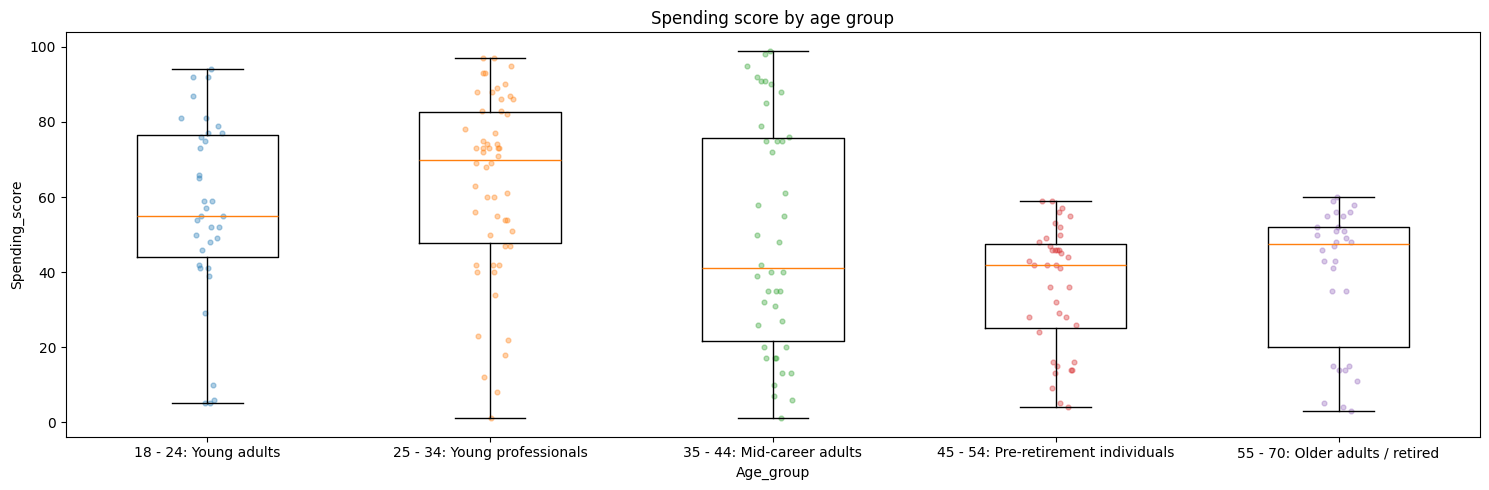

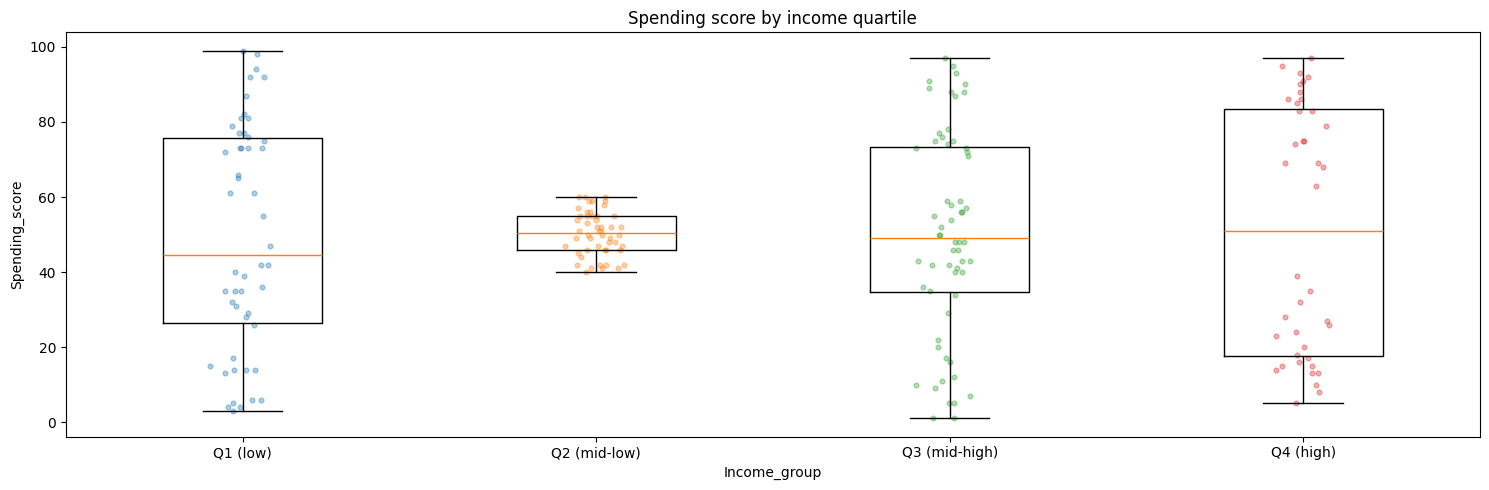

In [9]:
boxplot_by_group(
    df,
    value_col="Spending_score",
    group_col="Age_group",
    title="Spending score by age group",
    rotate_sticks=0,
)

boxplot_by_group(
    df,
    value_col="Spending_score",
    group_col="Income_group",
    title="Spending score by income quartile",
    rotate_sticks=0,
)

## 7.2 Group means

In [10]:
age_means = (
    df.groupby("Age_group")["Spending_score"]
      .agg(["count", "mean", "median", "std"])
      .sort_values("Age_group", ascending=True)
)
income_means = (
    df.groupby("Income_group")["Spending_score"]
      .agg(["count", "mean", "median", "std"])
      .sort_values("Income_group", ascending=True)
)

display(age_means)
display(income_means)

,count,mean,median,std
Age_group,,,,
18 - 24: Young adults,35,56.257143,55.0,24.659258
25 - 34: Young professionals,54,63.166667,70.0,24.283506
35 - 44: Mid-career adults,42,49.428571,41.0,30.700078
45 - 54: Pre-retirement individuals,39,36.230769,42.0,16.261776
55 - 70: Older adults / retired,30,39.033333,47.5,18.887112


,count,mean,median,std
Income_group,,,,
Q1 (low),50,49.480000,44.5,30.217740
Q2 (mid-low),50,50.380000,50.5,5.834066
Q3 (mid-high),60,50.133333,49.0,27.347399
Q4 (high),40,50.975000,51.0,32.862173


## 7.4 Age

### H0: mean spending score is equal across age groups
### H1: at least one age group differs

In [11]:
# H0_1: mean spending is equal across age groups
res_age = run_group_difference_test(
    df,
    value_col="Spending_score",
    group_col="Age_group",
    alpha=0.05,
    levene_center="median",  # Brown–Forsythe style
)
print(summarize_group_test(res_age))

Kruskal-Wallis on Spending_score by Age_group: stat=33.4676, p=0.0001%. Reject H0 at α=0.05. (k=5, n=200) Assumptions: Levene p=0.1199%; Shapiro p-values per group (NaN=skipped): {'18 - 24: Young adults': '4.8400%', '25 - 34: Young professionals': '0.7400%', '35 - 44: Mid-career adults': '0.9300%', '45 - 54: Pre-retirement individuals': '1.0500%', '55 - 70: Older adults / retired': '0.0300%'}. Rule used: Normality rejected in ≥1 group (Shapiro) -> Kruskal-Wallis as robust omnibus test. Effect size ε²=0.1511, 95% CI=(0.0849, 0.2666).


### Interpretation  

#### Combining the results from the table and hypothesis test, it is observed that at least one group’s spending score distribution is shifted relative to another (in terms of ranks).

## 7.5 Income

### H0: mean spending score is equal across income quartiles
### H1: at least one income group differs

In [12]:
# H0_2: mean spending is equal across income quartiles
res_income = run_group_difference_test(
    df,
    value_col="Spending_score",
    group_col="Income_group",
    alpha=0.05,
    levene_center="median",
)
print(summarize_group_test(res_income))

Kruskal-Wallis on Spending_score by Income_group: stat=0.1183, p=98.9550%. Fail to reject H0 at α=0.05. (k=4, n=200) Assumptions: Levene p=0.0000%; Shapiro p-values per group (NaN=skipped): {'Q1 (low)': '0.4500%', 'Q2 (mid-low)': '8.0300%', 'Q3 (mid-high)': '3.4100%', 'Q4 (high)': '0.0100%'}. Rule used: Normality rejected in ≥1 group (Shapiro) -> Kruskal-Wallis as robust omnibus test. Effect size ε²=-0.0147, 95% CI=(-0.0139, 0.0420).


### Interpretation  

#### Combining the results from the table and hypothesis test, there is no evidence that spending score distribution is shifted relative to another across income quartiles.

## 7.6 Dunn posthoc (Holm correction) test, effect size and CI

In [13]:
AGE_LABELS=["18 - 24: Young adults","25 - 34: Young professionals", "35 - 44: Mid-career adults", "45 - 54: Pre-retirement individuals", "55 - 70: Older adults / retired"]
income_labels=["Q1 (low)", "Q2 (mid-low)", "Q3 (mid-high)", "Q4 (high)"]

age_summary = group_descriptives(df, AGE_GROUP_COL, VALUE_COL, order=AGE_LABELS)
display(age_summary)

income_summary = group_descriptives(df, INCOME_GROUP_COL, VALUE_COL, order=income_labels)
display(income_summary)

,count,mean,median,std,iqr,min,max
Age_group,,,,,,,
18 - 24: Young adults,35,56.257143,55.0,24.659258,32.50,5,94
25 - 34: Young professionals,54,63.166667,70.0,24.283506,35.00,1,97
35 - 44: Mid-career adults,42,49.428571,41.0,30.700078,54.25,1,99
45 - 54: Pre-retirement individuals,39,36.230769,42.0,16.261776,22.50,4,59
55 - 70: Older adults / retired,30,39.033333,47.5,18.887112,32.00,3,60


,count,mean,median,std,iqr,min,max
Income_group,,,,,,,
Q1 (low),50,49.480000,44.5,30.217740,49.25,3,99
Q2 (mid-low),50,50.380000,50.5,5.834066,9.00,40,60
Q3 (mid-high),60,50.133333,49.0,27.347399,38.50,1,97
Q4 (high),40,50.975000,51.0,32.862173,65.75,5,97


In [14]:
age_pmat = dunn_posthoc_holm(df, AGE_GROUP_COL, VALUE_COL, order=AGE_LABELS)
display(age_pmat)

age_sig = significant_pairs_from_pmat(age_pmat, alpha=0.05)
display(age_sig)

,18 - 24: Young adults,25 - 34: Young professionals,35 - 44: Mid-career adults,45 - 54: Pre-retirement individuals,55 - 70: Older adults / retired
18 - 24: Young adults,1.000000,0.627703,0.627703,0.003054,0.050643
25 - 34: Young professionals,0.627703,1.000000,0.044593,0.000003,0.000701
35 - 44: Mid-career adults,0.627703,0.044593,1.000000,0.108923,0.627703
45 - 54: Pre-retirement individuals,0.003054,0.000003,0.108923,1.000000,0.627703
55 - 70: Older adults / retired,0.050643,0.000701,0.627703,0.627703,1.000000


,group_a,group_b,p_adj
0,25 - 34: Young professionals,45 - 54: Pre-retirement individuals,0.0003%
1,25 - 34: Young professionals,55 - 70: Older adults / retired,0.0701%
2,18 - 24: Young adults,45 - 54: Pre-retirement individuals,0.3054%
3,25 - 34: Young professionals,35 - 44: Mid-career adults,4.4593%


### Interpretation  

#### The table above shows which age groups differ significantly in their spending. Combing this with the previous tables (mean, median, std, IQR), it is observed that the 25-34 group's distribution is shifted higher compared to 45-54 and 55-70 group, while 18-24 is shifted higher compared to 45-54 group.

## 8. Next step  
### The clustering will be carried out on the original standardized features since the total variance explained by PC1 and PC2 is ~78%, meaning that the remaining ~22% will be left out. There are only 3 original features which are easily interpretable.